# ASL Alphabet Classification with Deep Learning
### IT3381 Applied Deep Learning Assignment, Part 1 (Computer Vision)

Author: Javian Ng

Notebook purpose: Build, train and compare two deep learning models, a CNN trained from scratch and a fine-tuned EfficientNetB0, to classify static hand-sign images of the American Sign Language (ASL) alphabet.

## 1. Introduction & Background

### 1.1 Problem statement

American Sign Language (ASL) is used by many Deaf and hard-of-hearing people in North America as their main language. If a model can recognise ASL alphabet letters from an image, it can be used in things like sign-to-text translation, apps for learning sign language, or tools to help people who don't know sign language communicate with signers. This is why the project falls under "AI for Social Good": it helps remove a communication barrier for a group that a lot of software doesn't really design for.

### 1.2 Why CNNs

ASL letters can look very similar to each other. For example, 'M', 'N', and 'S' are all closed fists with only small differences in finger position. Simple hand-crafted features like edges or HOG descriptors are not reliable enough to tell these apart, especially with different lighting, skin tones, and backgrounds. CNNs work better for this because:

* Convolution filters can learn small, local patterns (like finger edges or knuckle creases) straight from the pixels, so there's no need to manually design features.
* Stacking convolution layers lets the network build up from simple patterns (edges, textures) to more complex ones (like "two fingers extended"), which fits how hand shapes are actually made up of smaller parts.
* CNNs can handle a dataset this size and train reasonably fast on a GPU.

### 1.3 Scratch CNN vs. transfer learning

1. From-scratch CNN : a small VGG-style network built as a simple, controllable baseline. ASL images are less complex than something like ImageNet (plain background, one subject, similar framing every time), so a smaller model should still be able to learn the task without needing to be huge.
2.  Fine-tuned EfficientNetB0 : pre-trained on ImageNet, so it already knows general low-level and mid-level visual features. It was picked over VGG16 or ResNet50 because it uses compound scaling (Tan & Le, 2019), which balances depth, width, and resolution together, so it can match bigger models while having far fewer parameters (around 5M compared to ResNet50's 25M). That matters here since the model needs to be fine-tuned and used again without taking too long. Its MBConv blocks with squeeze-and-excitation attention also help it focus on the small finger and knuckle details that make similar handshapes different. Fine-tuning the last 30 layers lets the model adjust its higher-level features for hand shapes specifically, while keeping the pre-trained low-level filters. This usually trains faster and handles lighting or background changes better than the scratch CNN, but the trade-off is a bigger, more expensive model.

Comparing the two shows whether the extra size and complexity of a pre-trained, fine-tuned model is actually worth it for a task like this, where the images are fairly constrained to begin with.



### 1.4 Objectives

1. Prepare the ASL Alphabet dataset: load the ~87k training images, split them into stratified 80/10/10 train/validation/test, and apply augmentation.
2. Train a CNN from scratch (VGG-style, with batch norm, global average pooling, and dropout).
3. Fine-tune a pre-trained EfficientNetB0 (last 30 layers plus a new classifier head).
4. Evaluate both models on a held-out test set using suitable metrics.
5. Compare the strengths, weaknesses, and trade-offs of both models.
6. Export both trained models.


## 2. Setup: libraries and drive

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import shutil, json, time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from PIL import Image

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)
print("GPUs       :", tf.config.list_physical_devices("GPU"))


TensorFlow : 2.20.0
Keras      : 3.13.2
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
SEED = 1337
IMG_SIZE = 224
NUM_CLASSES = 29
BATCH_SCRATCH = 64
BATCH_EFFNET = 32

DRIVE_TRAIN_DIR = "/content/drive/MyDrive/asl-data/asl_alphabet_train/asl_alphabet_train"
DRIVE_TEST_DIR  = "/content/drive/MyDrive/asl-data/asl_alphabet_test/asl_alphabet_test"

DRIVE_TRAIN_ZIP = "/content/drive/MyDrive/asl-data/asl_alphabet_train.zip"

LOCAL_TRAIN_DIR = "/content/asl_train"
LOCAL_TEST_DIR  = "/content/asl_test"
OUT_DIR = "/content/drive/MyDrive/asl-data/outputs"
CHK_DIR = os.path.join(OUT_DIR, "chk")
EXPORT_DIR = os.path.join(OUT_DIR, "export")
REPORT_DIR = os.path.join(OUT_DIR, "report")
for d in (OUT_DIR, CHK_DIR, EXPORT_DIR, REPORT_DIR):
    os.makedirs(d, exist_ok=True)

try:
    for gpu in tf.config.list_physical_devices("GPU"):
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU memory growth enabled")
except Exception as exc:
    print("memory growth skipped:", exc)

keras.utils.set_random_seed(SEED)
print("Seed fixed:", SEED)


GPU memory growth enabled
Seed fixed: 1337


In [ ]:
import zipfile


def ensure_train_data():
    global LOCAL_TRAIN_DIR

    if os.path.exists(LOCAL_TRAIN_DIR) and os.listdir(LOCAL_TRAIN_DIR):
        print("train folder already local, skipping.")
        return

    if os.path.exists(DRIVE_TRAIN_ZIP):
        local_zip = "/content/asl_alphabet_train.zip"
        size_mb = os.path.getsize(DRIVE_TRAIN_ZIP) / 1e6
        print(f"copying train zip from Drive ({size_mb:.0f} MB, one file -> fast)...")
        shutil.copyfile(DRIVE_TRAIN_ZIP, local_zip)
        print("unzipping locally...")
        with zipfile.ZipFile(local_zip) as zf:
            zf.extractall(LOCAL_TRAIN_DIR)
        os.remove(local_zip)
        print("unzip complete.")
    else:
        print(f"no zip found at {DRIVE_TRAIN_ZIP} -> falling back to a direct folder copy "
              f"(slower: Drive FUSE has high per-file overhead on ~87,000 small images).")
        print("tip: to speed this up next time, zip the folder once inside Drive, e.g.")
        print(f'     !cd "{os.path.dirname(DRIVE_TRAIN_DIR)}" && '
              f'zip -rq asl_alphabet_train.zip asl_alphabet_train')
        shutil.copytree(DRIVE_TRAIN_DIR, LOCAL_TRAIN_DIR)
        print("folder copy complete.")

    for dirpath, dirnames, _ in os.walk(LOCAL_TRAIN_DIR):
        if len(dirnames) == NUM_CLASSES:
            LOCAL_TRAIN_DIR = dirpath
            break
    else:
        raise FileNotFoundError(
            f"could not find a folder with exactly {NUM_CLASSES} class subfolders "
            f"under {LOCAL_TRAIN_DIR} -- check the zip/folder structure."
        )


def copy_if_missing(src, dst, label):
    if not os.path.exists(dst):
        print(f"copying {label} folder from drive to local disk...")
        shutil.copytree(src, dst)
        print(f"{label} copy complete.")
    else:
        print(f"{label} folder already local, skipping copy.")


ensure_train_data()
copy_if_missing(DRIVE_TEST_DIR, LOCAL_TEST_DIR, "test")

print("LOCAL_TRAIN_DIR =", LOCAL_TRAIN_DIR)
print("LOCAL_TEST_DIR  =", LOCAL_TEST_DIR)


copying train zip from Drive (1101 MB, one file -> fast)...
unzipping locally...
unzip complete.
copying test folder from drive to local disk...
test copy complete.
LOCAL_TRAIN_DIR = /content/asl_train/asl_alphabet_train/asl_alphabet_train
LOCAL_TEST_DIR  = /content/asl_test


## 3. Combine Train + Test Pools, then Exploratory Data Analysis (EDA)
The raw Kaggle release ships a large per-class training folder and a small, separate
test folder (one held-out image per class, released by the dataset author). Since we
build our own stratified train/val/test split in section 4, both folders are merged
into a single labelled image pool first, so no labelled image goes unused. EDA below
then verifies there are 29 classes, counts images per class on the **combined** pool
to confirm the dataset is balanced, plots the class distribution as a bar chart, and
displays one random sample image per class to visually sanity-check the data.


In [ ]:
import re

class_names = sorted(os.listdir(LOCAL_TRAIN_DIR))
assert len(class_names) == NUM_CLASSES, f"expected {NUM_CLASSES} folders, got {len(class_names)}"
print("Classes:", class_names)


def collect_from_class_folders(root, names):

    paths, labels = [], []
    for idx, cname in enumerate(names):
        folder = os.path.join(root, cname)
        if not os.path.isdir(folder):
            continue
        for fname in sorted(os.listdir(folder)):
            paths.append(os.path.join(folder, fname))
            labels.append(idx)
    return paths, labels


def collect_from_flat_test(root, names):

    lookup = {c.lower(): i for i, c in enumerate(names)}
    paths, labels, unmatched = [], [], []
    for fname in sorted(os.listdir(root)):
        fpath = os.path.join(root, fname)
        if not os.path.isfile(fpath):
            continue
        stem = re.sub(r"_test$", "", os.path.splitext(fname)[0].lower())
        if stem in lookup:
            paths.append(fpath)
            labels.append(lookup[stem])
        else:
            unmatched.append(fname)
    if unmatched:
        print(f"  note: {len(unmatched)} test file(s) had no matching class, skipped -> {unmatched}")
    return paths, labels


train_paths, train_labels = collect_from_class_folders(LOCAL_TRAIN_DIR, class_names)

test_has_subfolders = any(
    os.path.isdir(os.path.join(LOCAL_TEST_DIR, d)) for d in os.listdir(LOCAL_TEST_DIR)
)
if test_has_subfolders:
    test_paths, test_labels = collect_from_class_folders(LOCAL_TEST_DIR, class_names)
else:
    test_paths, test_labels = collect_from_flat_test(LOCAL_TEST_DIR, class_names)

print(f"train folder : {len(train_paths):,} images")
print(f"test folder  : {len(test_paths):,} images")

paths = np.array(train_paths + test_paths)
labels = np.array(train_labels + test_labels)
print(f"combined pool: {len(paths):,} images across {len(class_names)} classes")

counts = {class_names[i]: int((labels == i).sum()) for i in range(NUM_CLASSES)}
sizes = np.array(list(counts.values()))
print(f"Total images : {sizes.sum():,}")
print(f"Per-class    : min={sizes.min()}  max={sizes.max()}  (native images are 200x200)")

tolerance = 0.05 * sizes.mean()
assert sizes.max() - sizes.min() <= tolerance, "unexpected class imbalance"
print("Balance check passed.")


Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
train folder : 87,000 images
test folder  : 0 images
combined pool: 87,000 images across 29 classes
Total images : 87,000
Per-class    : min=3000  max=3000  (native images are 200x200)
Balance check passed.


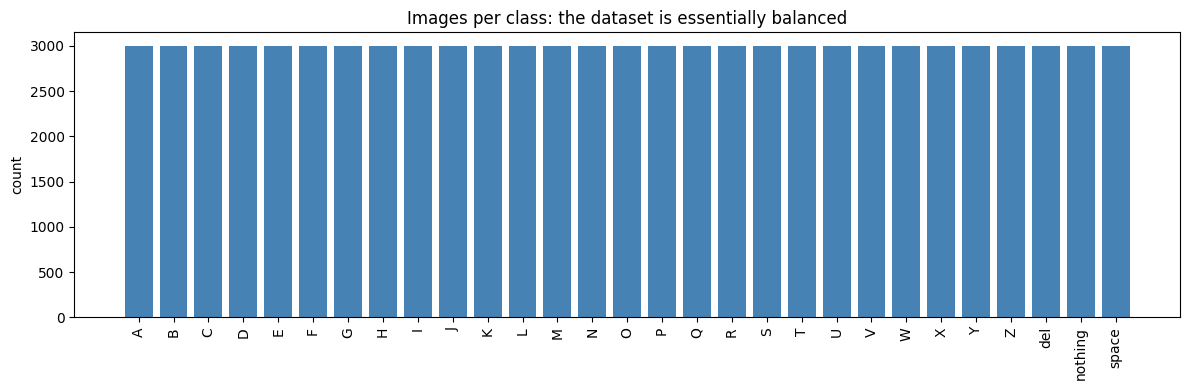

In [ ]:
plt.figure(figsize=(12, 4))
plt.bar(counts.keys(), counts.values(), color="steelblue")
plt.title("Images per class: the dataset is essentially balanced")
plt.ylabel("count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


From this, we can see that all 29 classes have 3,000 samples each meaning no data imbalance is happening here. This also means that later during the model evaluation stage, accuracy becomes a viable metric to evaluate the model upon.

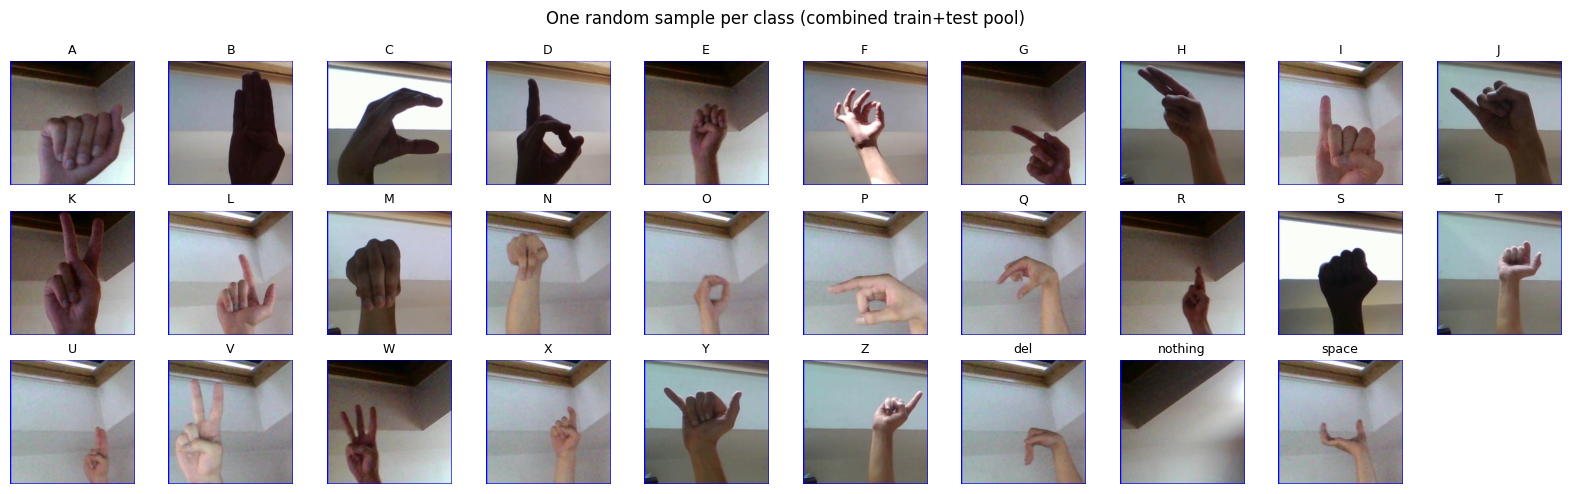

In [ ]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(3, 10, figsize=(16, 5))
for ax, cname in zip(axes.ravel(), class_names):
    idx = class_names.index(cname)
    class_paths = paths[labels == idx]
    pick = rng.choice(class_paths)
    img = Image.open(pick).convert("RGB")
    ax.imshow(img)
    ax.set_title(cname, fontsize=9)
    ax.axis("off")
for ax in axes.ravel()[len(class_names):]:
    ax.axis("off")
plt.suptitle("One random sample per class (combined train+test pool)")
plt.tight_layout()
plt.show()


## 4. Stratified 80/10/10 Split
Using the combined `paths` / `labels` pool built in section 3 (training folder +
test folder merged together), performs a stratified 80/10/10 split into
train/validation/test sets so each class is proportionally represented in all
three. Also checks that every class has at least one image in every split and
prints a summary table of counts per class.


In [ ]:
tr_paths, tmp_paths, tr_labels, tmp_labels = train_test_split(
    paths, labels, test_size=0.20, stratify=labels, random_state=SEED)
va_paths, te_paths, va_labels, te_labels = train_test_split(
    tmp_paths, tmp_labels, test_size=0.50, stratify=tmp_labels, random_state=SEED)

for split_name, ys in [("train", tr_labels), ("val", va_labels), ("test", te_labels)]:
    for cls in range(NUM_CLASSES):
        assert (ys == cls).sum() >= 1, f"class {class_names[cls]} missing from {split_name}"
print("every class present in every split")
print("sizes -> train/val/test:", len(tr_paths), "/", len(va_paths), "/", len(te_paths))


every class present in every split
sizes -> train/val/test: 69600 / 8700 / 8700


In [ ]:
table = pd.DataFrame({
    "class": class_names,
    "train": [(tr_labels == i).sum() for i in range(NUM_CLASSES)],
    "val":   [(va_labels == i).sum() for i in range(NUM_CLASSES)],
    "test":  [(te_labels == i).sum() for i in range(NUM_CLASSES)]
})
print(table.head(8).to_string(index=False))
print("...")
print("min per class:", table[["train", "val", "test"]].min().to_dict())
print("totals       :", table[["train", "val", "test"]].sum().to_dict())
display(table)


class  train  val  test
    A   2400  300   300
    B   2400  300   300
    C   2400  300   300
    D   2400  300   300
    E   2400  300   300
    F   2400  300   300
    G   2400  300   300
    H   2400  300   300
...
min per class: {'train': 2400, 'val': 300, 'test': 300}
totals       : {'train': 69600, 'val': 8700, 'test': 8700}


,class,train,val,test
0,A,2400,300,300
1,B,2400,300,300
2,C,2400,300,300
3,D,2400,300,300
4,E,2400,300,300
5,F,2400,300,300
6,G,2400,300,300
7,H,2400,300,300
8,I,2400,300,300
9,J,2400,300,300


## 5. Input Pipelines (`tf.data`)
Defines a `tf.data` pipeline that reads each image file, decodes it, and resizes it to 224×224, then wraps it into batched, prefetched datasets for training, validation, and testing. Builds those three datasets and runs a quick check on batch shape, pixel range, and per-batch loading speed to confirm the pipeline is working efficiently.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def decode_and_resize(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return tf.cast(img, tf.float32), label

def make_dataset(paths, labels, training, batch_size=BATCH_SCRATCH):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(2048, seed=SEED)
    return ds.batch(batch_size).prefetch(AUTOTUNE)


In [ ]:
train_ds = make_dataset(tr_paths, tr_labels, training=True, batch_size=BATCH_SCRATCH)
val_ds   = make_dataset(va_paths, va_labels, training=False, batch_size=BATCH_SCRATCH)
test_ds  = make_dataset(te_paths, te_labels, training=False, batch_size=BATCH_SCRATCH)

for images, lbls in train_ds.take(1):
    print("batch images:", images.shape, images.dtype,
          "| pixel range:", float(images.numpy().min()), "-", float(images.numpy().max()))
    print("batch labels:", lbls.shape, lbls.dtype, "->", lbls.numpy()[:8])

t0 = time.perf_counter()
for _ in train_ds.take(20):
    pass
print(f"pipeline speed ~{(time.perf_counter() - t0) / 20 * 1000:.0f} ms per training batch")


batch images: (64, 224, 224, 3) <dtype: 'float32'> | pixel range: 0.0 - 255.0
batch labels: (64,) <dtype: 'int64'> -> [ 6 14 14  7  3  6 27 22]
pipeline speed ~25 ms per training batch


## 6. Data Augmentation (shared by both models)
Defines the shared augmentation stack (small random rotation, zoom, translation, brightness, and contrast changes) that both models will use during training. Applies it to one sample image several times and plots the results side by side with the original, to visually confirm the augmentations are reasonable and not too aggressive.

In [ ]:
def make_augmentation():
    return [
        layers.RandomRotation(0.04),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomBrightness(0.15),
        layers.RandomContrast(0.15)
    ]

print("shared augmentation recipe:")
for aug in make_augmentation():
    print("  -", aug.__class__.__name__)


shared augmentation recipe:
  - RandomRotation
  - RandomZoom
  - RandomTranslation
  - RandomBrightness
  - RandomContrast


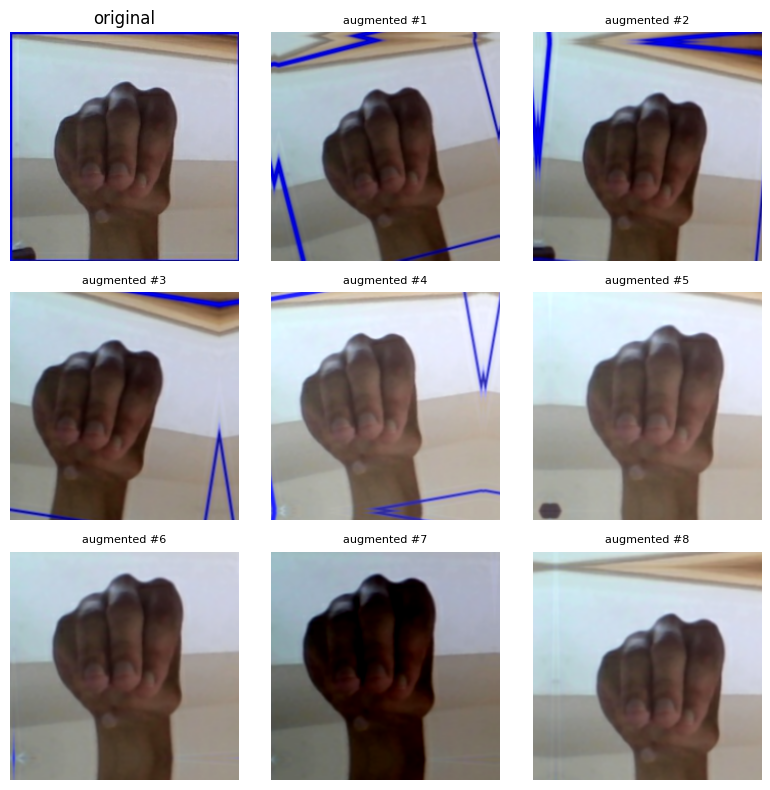

In [ ]:
raw = tf.io.read_file(tr_paths[0])
img = tf.image.resize(tf.image.decode_jpeg(raw, channels=3), [IMG_SIZE, IMG_SIZE])
preview_stack = keras.Sequential(make_augmentation())

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
axes[0, 0].imshow(img.numpy().astype("uint8"))
axes[0, 0].set_title("original")
for k in range(1, 9):
    out = preview_stack(tf.expand_dims(img, 0), training=True)
    axes.ravel()[k].imshow(tf.clip_by_value(out[0], 0, 255).numpy().astype("uint8"))
    axes.ravel()[k].set_title(f"augmented #{k}", fontsize=8)
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()


## 7. Model 1: Scratch CNN
Builds a small VGG-style CNN from scratch, with the augmentation layer, four convolutional blocks (each using batch norm and ReLU), global average pooling, dropout, and a dense classification head. Compiles it with Adam and sparse categorical cross-entropy, then prints the full model summary and total parameter count.

In [ ]:
scratch_model = keras.Sequential(
    [
        keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        keras.Sequential(make_augmentation(), name="augmentation"),
        layers.Rescaling(1./255),

        layers.Conv2D(32, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(128, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(256, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(128, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="asl_scratch_cnn"
)

scratch_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

scratch_model.summary()
print(f"\nTotal parameters: {scratch_model.count_params():,}")


Model: "asl_scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 256)    │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 1,165,309 (4.45 MB)

 Trainable params: 1,163,581 (4.44 MB)

 Non-trainable params: 1,728 (6.75 KB)


Total parameters: 1,165,309


## 8. Model 2: Transfer Learning (EfficientNetB0)
Loads EfficientNetB0 pretrained on ImageNet with its backbone frozen, attaches the shared augmentation layer, a global average pooling layer, dropout, and a new dense classification head on top. Compiles the model and prints how many parameters are trainable (the new head) versus frozen (the backbone), to make the transfer-learning setup explicit.

In [ ]:
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = keras.Sequential(make_augmentation(), name="augmentation")(inputs)

base = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base.trainable = False

x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

effnet_model = keras.Model(inputs, outputs, name="asl_efficientnetb0_finetuned")

effnet_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

trainable_p = sum(int(np.prod(w.shape)) for w in effnet_model.trainable_weights)
total_p = effnet_model.count_params()
print(f"total parameters  : {total_p:,}")
print(f"trainable (head)  : {trainable_p:,}")
print(f"frozen (backbone) : {total_p - trainable_p:,}")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
total parameters  : 4,384,960
trainable (head)  : 335,389
frozen (backbone) : 4,049,571


## 9. Train the Scratch CNN:
Defines the shared training callbacks: checkpointing the best weights by validation accuracy, early stopping on validation loss, reducing the learning rate on plateau, and logging history to CSV. Trains the scratch CNN for up to 25 epochs using these callbacks, with training and validation metrics printed after every epoch.

In [ ]:
def make_callbacks(name, patience):
    return [
        keras.callbacks.ModelCheckpoint(
            os.path.join(CHK_DIR, name + ".keras"),
            monitor="val_accuracy", save_best_only=True),
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
        keras.callbacks.CSVLogger(
            os.path.join(REPORT_DIR, name + "_history.csv"), append=False)
    ]


In [ ]:
hist_scratch = scratch_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=make_callbacks("scratch_cnn", patience=4)
)


Epoch 1/25
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 279s 247ms/step - accuracy: 0.5222 - loss: 1.5117 - val_accuracy: 0.7760 - val_loss: 0.6189 - learning_rate: 0.0010
Epoch 2/25
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 265s 243ms/step - accuracy: 0.8764 - loss: 0.3656 - val_accuracy: 0.8553 - val_loss: 0.3649 - learning_rate: 0.0010
Epoch 3/25
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 265s 243ms/step - accuracy: 0.9399 - loss: 0.1863 - val_accuracy: 0.8770 - val_loss: 0.3351 - learning_rate: 0.0010
Epoch 4/25
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 265s 243ms/step - accuracy: 0.9639 - loss: 0.1123 - val_accuracy: 0.9631 - val_loss: 0.1155 - learning_rate: 0.0010
Epoch 5/25
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 264s 243ms/step - accuracy: 0.9736 - loss: 0.0833 - val_accuracy: 0.9507 - val_loss: 0.1326 - learning_rate: 0.0010
Epoch 6/25
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 264s 243ms/step - accuracy: 0.9797 - loss: 0.0635 - val_accuracy: 0.9593 - val_loss: 0.1165 - learning_rate: 0.0010
Epoch 7/25
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 264s 243ms

 Reading the run below:  `epochs run < 25` means EarlyStopping fired; the reported
best validation accuracy corresponds to the weights actually kept (restored by the
callback), not necessarily to the final epoch.

In [ ]:
h = hist_scratch.history
print(f"epochs run       : {len(hist_scratch.epoch)}")
print(f"best val accuracy: {max(h['val_accuracy']):.4f}")
print(f"final train loss : {h['loss'][-1]:.4f}")
print(f"final val loss   : {h['val_loss'][-1]:.4f}")


epochs run       : 19
best val accuracy: 1.0000
final train loss : 0.0038
final val loss   : 0.0008


## 10. Two-Phase Training: EfficientNetB0:
Rebuilds the training dataset at a smaller batch size (32, vs. 64 for the scratch CNN) to suit EfficientNetB0's higher memory footprint. Runs "phase 1" training with the pretrained backbone still frozen, so only the new classification head is being trained for up to 10 epochs.

In [ ]:
train_ds_b32 = make_dataset(tr_paths, tr_labels, training=True, batch_size=BATCH_EFFNET)

hist_p1 = effnet_model.fit(
    train_ds_b32,
    validation_data=val_ds,
    epochs=10,
    callbacks=make_callbacks("effnet_phase1", patience=3)
)
print("after phase 1, in-memory weights = BEST phase-1 weights (restored by callback)")


Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 128s 54ms/step - accuracy: 0.8169 - loss: 0.5957 - val_accuracy: 0.9578 - val_loss: 0.1246 - learning_rate: 0.0010
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 116s 53ms/step - accuracy: 0.8986 - loss: 0.3062 - val_accuracy: 0.9764 - val_loss: 0.0714 - learning_rate: 0.0010
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 116s 53ms/step - accuracy: 0.9132 - loss: 0.2548 - val_accuracy: 0.9793 - val_loss: 0.0582 - learning_rate: 0.0010
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 116s 53ms/step - accuracy: 0.9270 - loss: 0.2163 - val_accuracy: 0.9815 - val_loss: 0.0540 - learning_rate: 0.0010
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 116s 53ms/step - accuracy: 0.9339 - loss: 0.1946 - val_accuracy: 0.9811 - val_loss: 0.0500 - learning_rate: 0.0010
Epoch 6/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 117s 53ms/step - accuracy: 0.9391 - loss: 0.1809 - val_accuracy: 0.9874 - val_loss: 0.0385 - learning_rate: 0.0010
Epoch 7/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 117s 54ms/step -

### Why BatchNorm stays frozen:

Unfreezes the last 30 layers of the EfficientNetB0 backbone so they can be fine-tuned on the ASL data, while explicitly keeping their BatchNorm sub-layers frozen. This preserves the ImageNet-derived running statistics in those layers, since letting them keep updating on a much smaller, different dataset tends to destabilize calibration and hurt accuracy this is standard practice when fine-tuning on limited data.

In [ ]:
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

kept_frozen = 0
for layer in base.layers[-30:]:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False
        kept_frozen += 1
n_open = sum(1 for layer in base.layers[-30:] if layer.trainable)
print(f"last 30 backbone layers: {n_open} trainable, {kept_frozen} BatchNorm kept frozen")


last 30 backbone layers: 23 trainable, 7 BatchNorm kept frozen


In [ ]:
effnet_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

hist_p2 = effnet_model.fit(
    train_ds_b32,
    validation_data=val_ds,
    epochs=10,
    callbacks=make_callbacks("effnet_phase2", patience=3)
)


Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 138s 58ms/step - accuracy: 0.9761 - loss: 0.0701 - val_accuracy: 0.9959 - val_loss: 0.0134 - learning_rate: 1.0000e-05
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 125s 57ms/step - accuracy: 0.9852 - loss: 0.0441 - val_accuracy: 0.9970 - val_loss: 0.0103 - learning_rate: 1.0000e-05
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 125s 58ms/step - accuracy: 0.9881 - loss: 0.0343 - val_accuracy: 0.9970 - val_loss: 0.0080 - learning_rate: 1.0000e-05
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 125s 57ms/step - accuracy: 0.9903 - loss: 0.0287 - val_accuracy: 0.9979 - val_loss: 0.0073 - learning_rate: 1.0000e-05
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 125s 58ms/step - accuracy: 0.9909 - loss: 0.0270 - val_accuracy: 0.9980 - val_loss: 0.0057 - learning_rate: 1.0000e-05
Epoch 6/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 125s 57ms/step - accuracy: 0.9927 - loss: 0.0219 - val_accuracy: 0.9990 - val_loss: 0.0044 - learning_rate: 1.0000e-05
Epoch 7/10
2175/2175 ━━━━━━━━━━━━━

In [ ]:
boundary = len(hist_p1.epoch)
merged_hist = {key: hist_p1.history[key] + hist_p2.history[key]
               for key in hist_p1.history}

pd.DataFrame(merged_hist).to_csv(
    os.path.join(REPORT_DIR, "effnet_history_merged.csv"), index=False)
print(f"merged history: {len(merged_hist['loss'])} epochs "
      f"(fine-tune phase starts at epoch index {boundary})")
print(f"best val accuracy overall: {max(merged_hist['val_accuracy']):.4f}")


merged history: 20 epochs (fine-tune phase starts at epoch index 10)
best val accuracy overall: 0.9995


## 11. Final Evaluation using unseen test set:

Reloads both saved models from disk and evaluates them on the untouched test set to get final accuracy numbers, then generates predictions to compute classification reports and macro-F1 scores. Also builds confusion matrices, per-class F1 bar charts, a table of the most-confused class pairs, a gallery of misclassified scratch-CNN images, and a latency benchmark that times single-image inference for both models using the same preprocessing the web app will use.

In [ ]:
scratch_model.save(os.path.join(EXPORT_DIR, "asl_scratch_cnn.keras"))
effnet_model.save(os.path.join(EXPORT_DIR, "asl_efficientnetb0_finetuned.keras"))

loaded_scratch = keras.models.load_model(
    os.path.join(EXPORT_DIR, "asl_scratch_cnn.keras"), compile=False)
loaded_effnet = keras.models.load_model(
    os.path.join(EXPORT_DIR, "asl_efficientnetb0_finetuned.keras"), compile=False)

for mdl in (loaded_scratch, loaded_effnet):
    mdl.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"]
    )

test_acc_scratch = loaded_scratch.evaluate(test_ds, verbose=0)[1]
test_acc_effnet = loaded_effnet.evaluate(test_ds, verbose=0)[1]
print(f"Scratch CNN                 test accuracy: {test_acc_scratch:.4f}")
print(f"EfficientNetB0 (fine-tuned) test accuracy: {test_acc_effnet:.4f}")


Scratch CNN                 test accuracy: 0.9999
EfficientNetB0 (fine-tuned) test accuracy: 0.9991


In [ ]:

preds_s = loaded_scratch.predict(test_ds, verbose=0)
preds_e = loaded_effnet.predict(test_ds, verbose=0)
y_pred_s = np.argmax(preds_s, axis=1)
y_pred_e = np.argmax(preds_e, axis=1)
assert len(y_pred_s) == len(te_labels) == len(y_pred_e)

for tag, y_hat in [("scratch", y_pred_s), ("efficientnet", y_pred_e)]:
    txt = classification_report(te_labels, y_hat, target_names=class_names)
    with open(os.path.join(REPORT_DIR, f"classification_report_{tag}.txt"), "w") as fh:
        fh.write(txt)

f1_scratch = f1_score(te_labels, y_pred_s, average="macro")
f1_effnet = f1_score(te_labels, y_pred_e, average="macro")
print(f"macro F1 -> scratch: {f1_scratch:.4f} | efficientnet: {f1_effnet:.4f}")


macro F1 -> scratch: 0.9999 | efficientnet: 0.9991


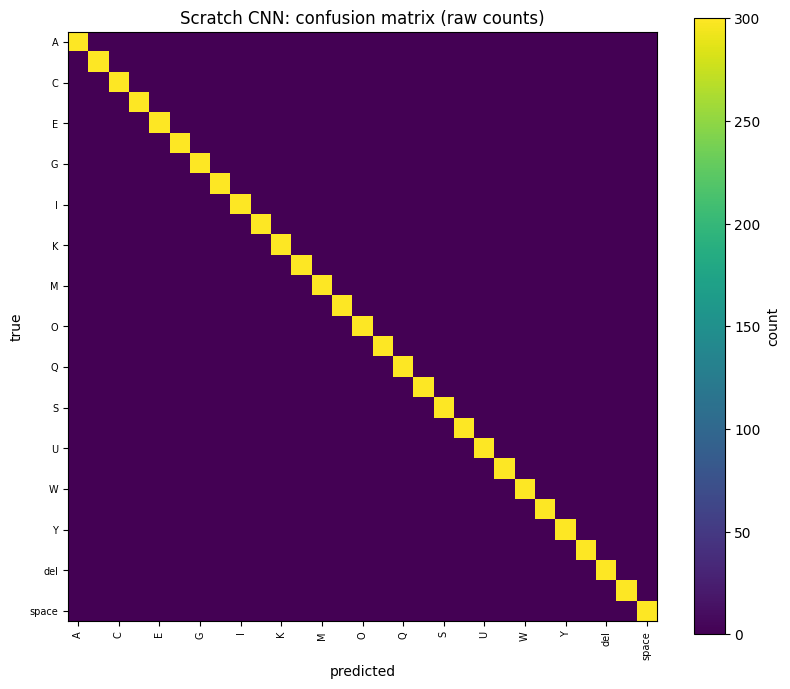

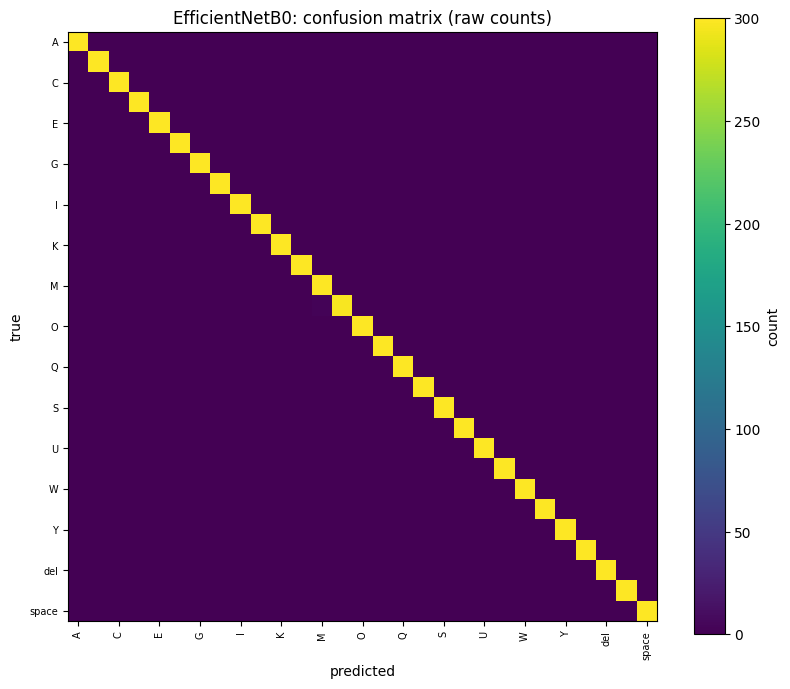

In [ ]:
cm_s = confusion_matrix(te_labels, y_pred_s) # print confusion matrix for scratch cnn
cm_e = confusion_matrix(te_labels, y_pred_e) # print confusion matrix for efficientnet


def plot_cm(cm, title, fname):
    fig, ax = plt.subplots(figsize=(9.5, 8))
    im = ax.imshow(cm, cmap="viridis")
    fig.colorbar(im, ax=ax, label="count")
    ticks = np.arange(0, NUM_CLASSES, 2)
    ax.set_xticks(ticks)
    ax.set_xticklabels([class_names[i] for i in ticks], rotation=90, fontsize=7)
    ax.set_yticks(ticks)
    ax.set_yticklabels([class_names[i] for i in ticks], fontsize=7)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)
    fig.savefig(os.path.join(REPORT_DIR, fname), dpi=130, bbox_inches="tight")
    plt.show()


plot_cm(cm_s, "Scratch CNN: confusion matrix (raw counts)",
        "confusion_matrix_scratch.png")
plot_cm(cm_e, "EfficientNetB0: confusion matrix (raw counts)",
        "confusion_matrix_efficientnet.png")


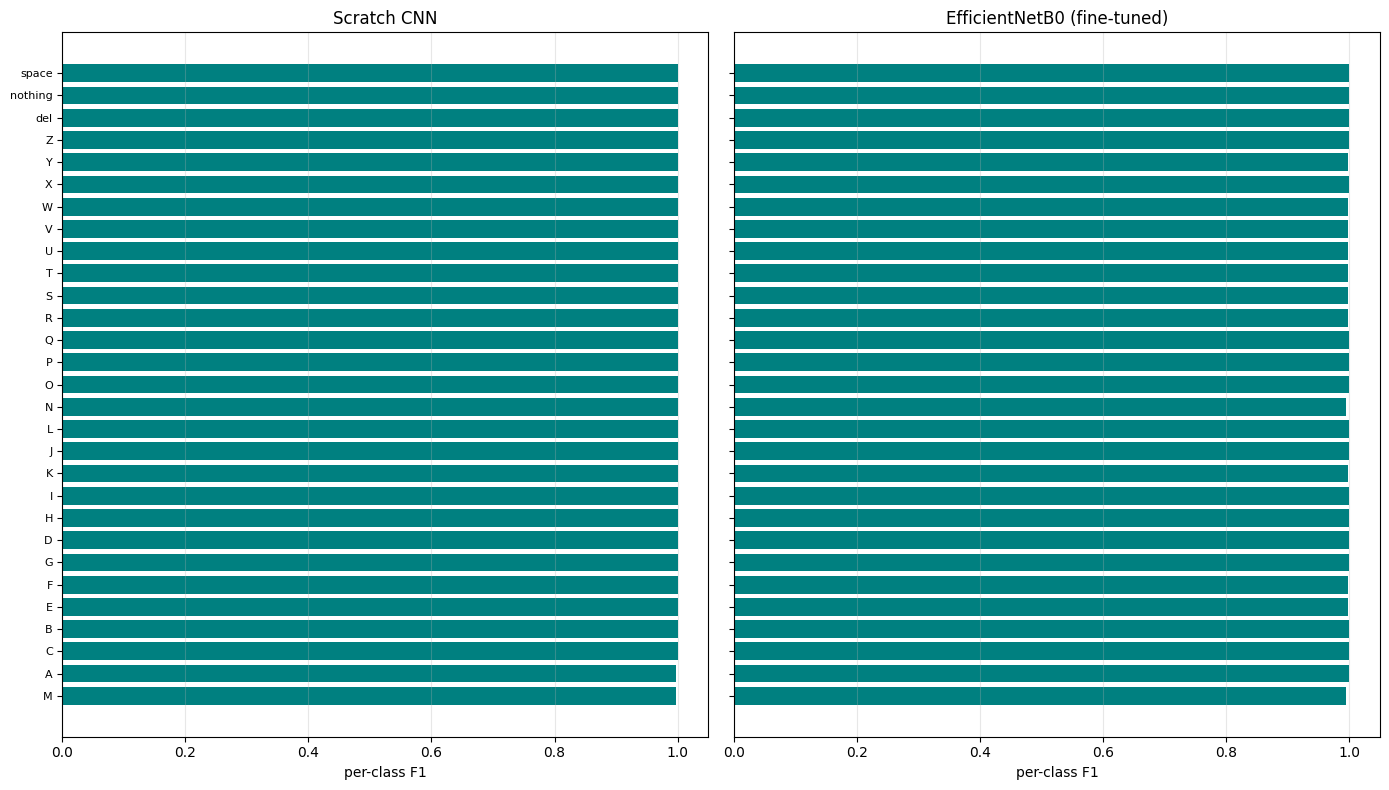

In [ ]:
f1s_s = f1_score(te_labels, y_pred_s, average=None)
f1s_e = f1_score(te_labels, y_pred_e, average=None)
order = np.argsort(f1s_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
for ax, f1s, name in [(axes[0], f1s_s, "Scratch CNN"),
                      (axes[1], f1s_e, "EfficientNetB0 (fine-tuned)")]:
    ax.barh(np.arange(NUM_CLASSES), f1s[order], color="teal")
    ax.set_yticks(np.arange(NUM_CLASSES))
    ax.set_yticklabels([class_names[i] for i in order], fontsize=8)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("per-class F1")
    ax.set_title(name)
    ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(REPORT_DIR, "per_class_f1.png"), dpi=130)
plt.show()


In [ ]:
def top_confused(cm, k=10):
    off = cm.astype(float).copy()
    np.fill_diagonal(off, -1.0)
    rows = []
    for _ in range(k):
        i, j = np.unravel_index(np.argmax(off), off.shape)
        if off[i, j] <= 0:
            break
        rows.append({"true": class_names[i], "predicted": class_names[j],
                     "count": int(cm[i, j])})
        off[i, j] = -1.0
    return pd.DataFrame(rows)


print("Scratch CNN: most confused pairs:")
print(top_confused(cm_s).to_string(index=False))
print("\nEfficientNetB0: most confused pairs:")
print(top_confused(cm_e).to_string(index=False))

top_confused(cm_s).to_csv(
    os.path.join(REPORT_DIR, "confused_pairs_scratch.csv"), index=False)
top_confused(cm_e).to_csv(
    os.path.join(REPORT_DIR, "confused_pairs_efficientnet.csv"), index=False)


Scratch CNN: most confused pairs:
true predicted  count
   M         A      1

EfficientNetB0: most confused pairs:
true predicted  count
   N         M      3
   E         S      1
   F         K      1
   U         R      1
   W         V      1
   Y         T      1


1 / 8700 test images misclassified by Scratch CNN


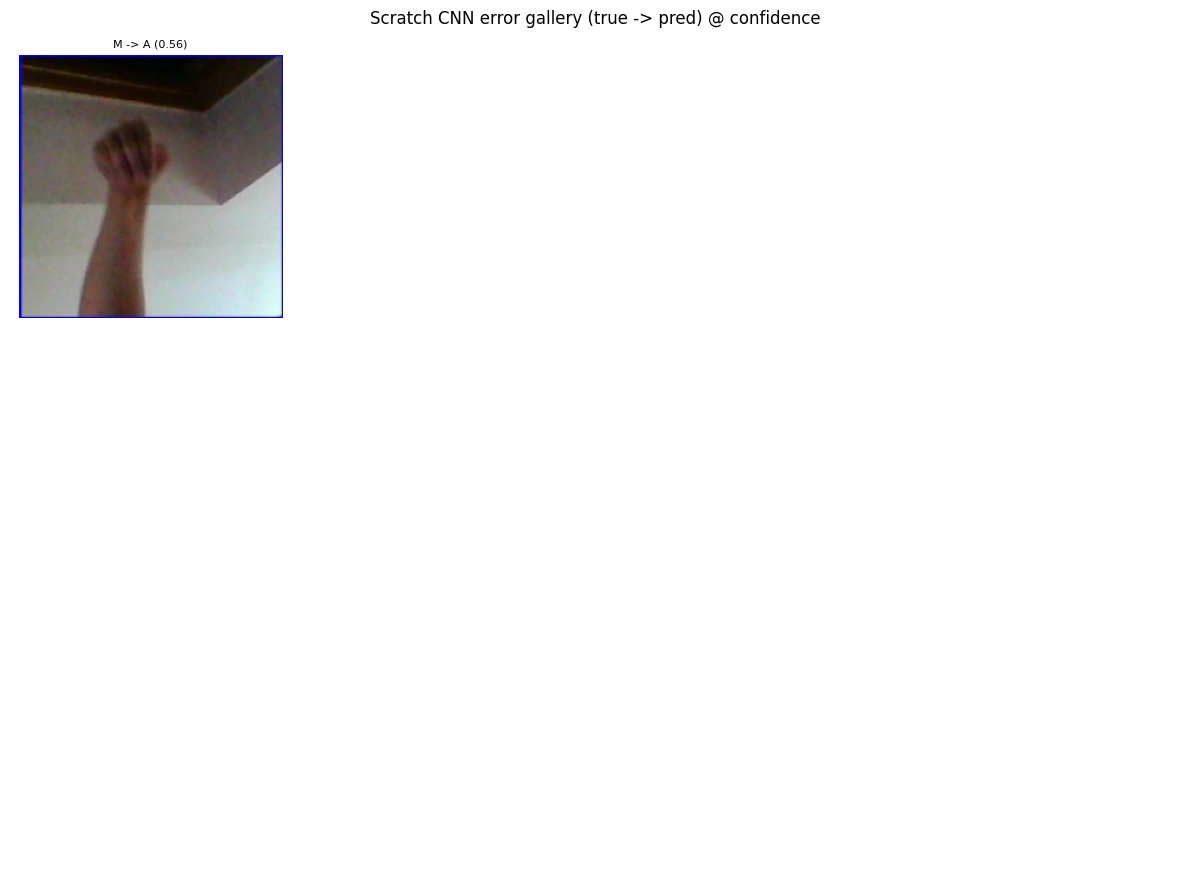

In [ ]:
wrong_idx = np.where(y_pred_s != te_labels)[0]
print(f"{len(wrong_idx)} / {len(te_labels)} test images misclassified by Scratch CNN")
show = wrong_idx[:12]

if len(show):
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    for ax, idx in zip(axes.ravel(), show):
        img = Image.open(te_paths[idx]).convert("RGB").resize(
            (IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        conf = preds_s[idx, y_pred_s[idx]]
        ax.imshow(img)
        ax.set_title(f"{class_names[te_labels[idx]]} -> "
                     f"{class_names[y_pred_s[idx]]} ({conf:.2f})", fontsize=8)
        ax.axis("off")
    for ax in axes.ravel()[len(show):]:
        ax.axis("off")
    fig.suptitle("Scratch CNN error gallery (true -> pred) @ confidence")
    fig.tight_layout()
    fig.savefig(os.path.join(REPORT_DIR, "error_gallery.png"), dpi=130)
    plt.show()


In [ ]:
def webapp_style_input(path):
    img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    return np.asarray(img, dtype=np.float32)[None, ...]


def bench_latency(model, sample_paths, n=50):
    model.predict(webapp_style_input(sample_paths[0]), verbose=0)
    timings = []
    for p in sample_paths[1:n + 1]:
        x = webapp_style_input(p)
        t0 = time.perf_counter()
        model.predict(x, verbose=0)
        timings.append((time.perf_counter() - t0) * 1000.0)
    return float(np.mean(timings)), float(np.percentile(timings, 95))


lat_s_mean, lat_s_p95 = bench_latency(loaded_scratch, te_paths)
lat_e_mean, lat_e_p95 = bench_latency(loaded_effnet, te_paths)
print(f"Scratch CNN       mean {lat_s_mean:6.1f} ms | p95 {lat_s_p95:6.1f} ms")
print(f"EfficientNetB0    mean {lat_e_mean:6.1f} ms | p95 {lat_e_p95:6.1f} ms")

bench_df = pd.DataFrame([
    {"Model": "Scratch CNN", "mean_ms": lat_s_mean, "p95_ms": lat_s_p95},
    {"Model": "EfficientNetB0 (fine-tuned)",
     "mean_ms": lat_e_mean, "p95_ms": lat_e_p95}
])
bench_df.to_csv(os.path.join(REPORT_DIR, "latency_benchmark.csv"), index=False)


Scratch CNN       mean   78.5 ms | p95   81.9 ms
EfficientNetB0    mean   86.1 ms | p95   88.2 ms


## 12. Head-to-Head Comparison
Assembles a single comparison table pulling together test accuracy, parameter count, epochs trained, validation accuracy, macro-F1, latency, and file size for both models side by side. Visualises this as a grouped bar chart (accuracy/F1) plus a bubble scatter plot (parameters vs. accuracy, bubble size ~ latency), and separately plots both models' full training curves (accuracy and loss over epochs) for comparison.


In [ ]:
params_scratch = int(loaded_scratch.count_params())
params_effnet = int(loaded_effnet.count_params())

size_mb_scratch = os.path.getsize(
    os.path.join(EXPORT_DIR, "asl_scratch_cnn.keras")) / 1e6
size_mb_effnet = os.path.getsize(
    os.path.join(EXPORT_DIR, "asl_efficientnetb0_finetuned.keras")) / 1e6

comparison_df = pd.DataFrame([
    {"Model": "Scratch CNN",
     "Test Accuracy": test_acc_scratch,
     "Total Params": params_scratch,
     "Epochs Trained": len(hist_scratch.epoch),
     "Val Accuracy": max(hist_scratch.history["val_accuracy"]),
     "Macro F1": f1_scratch,
     "Latency ms": lat_s_mean,
     "File Size MB": size_mb_scratch},
    {"Model": "EfficientNetB0 (fine-tuned)",
     "Test Accuracy": test_acc_effnet,
     "Total Params": params_effnet,
     "Epochs Trained": len(hist_p1.epoch) + len(hist_p2.epoch),
     "Val Accuracy": max(merged_hist["val_accuracy"]),
     "Macro F1": f1_effnet,
     "Latency ms": lat_e_mean,
     "File Size MB": size_mb_effnet}
])

try:
    display(comparison_df.style.hide(axis="index").format(precision=3))
except Exception:
    print(comparison_df.to_string(index=False))


Model,Test Accuracy,Total Params,Epochs Trained,Val Accuracy,Macro F1,Latency ms,File Size MB
Scratch CNN,1.000,1165309,19,1.000,1.000,78.470,14.096
EfficientNetB0 (fine-tuned),0.999,4384960,20,1.000,0.999,86.135,32.967


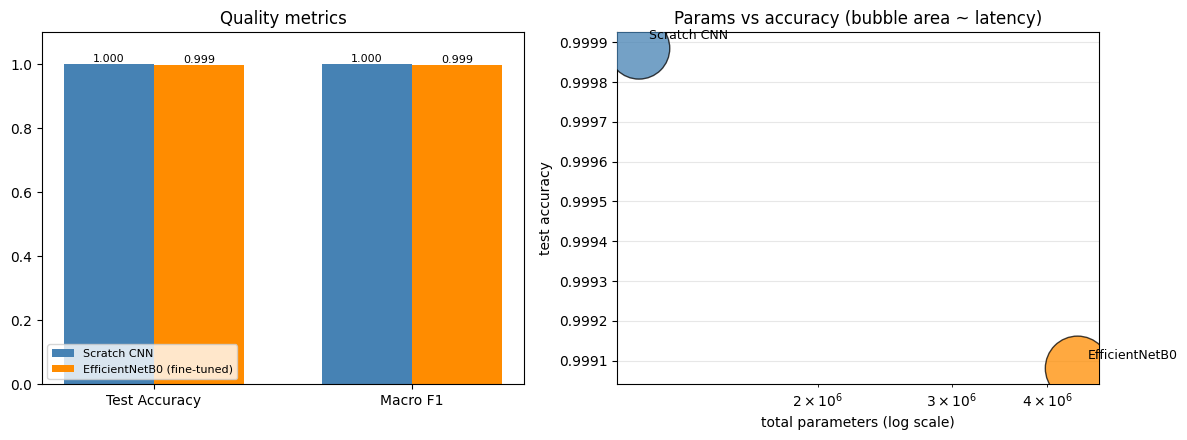

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
s_vals = [comparison_df.loc[0, "Test Accuracy"], comparison_df.loc[0, "Macro F1"]]
e_vals = [comparison_df.loc[1, "Test Accuracy"], comparison_df.loc[1, "Macro F1"]]
b1 = ax.bar(np.arange(2) - 0.175, s_vals, 0.35, label="Scratch CNN", color="steelblue")
b2 = ax.bar(np.arange(2) + 0.175, e_vals, 0.35,
            label="EfficientNetB0 (fine-tuned)", color="darkorange")
ax.bar_label(b1, fmt="%.3f", fontsize=8)
ax.bar_label(b2, fmt="%.3f", fontsize=8)
ax.set_xticks(np.arange(2))
ax.set_xticklabels(["Test Accuracy", "Macro F1"])
ax.set_ylim(0, 1.1)
ax.legend(fontsize=8)
ax.set_title("Quality metrics")

ax = axes[1]
bubble = np.clip([lat_s_mean * 25, lat_e_mean * 25], 40, None)
xs = [params_scratch, params_effnet]
ys = [test_acc_scratch, test_acc_effnet]
ax.scatter(xs, ys, s=bubble, c=["steelblue", "darkorange"],
           alpha=0.75, edgecolor="black", zorder=3)
for xi, yi, nm in zip(xs, ys, ["Scratch CNN", "EfficientNetB0"]):
    ax.annotate(nm, (xi, yi), xytext=(7, 7), textcoords="offset points", fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("total parameters (log scale)")
ax.set_ylabel("test accuracy")
ax.set_title("Params vs accuracy (bubble area ~ latency)")
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(os.path.join(REPORT_DIR, "comparison_bars_scatter.png"), dpi=130)
plt.show()


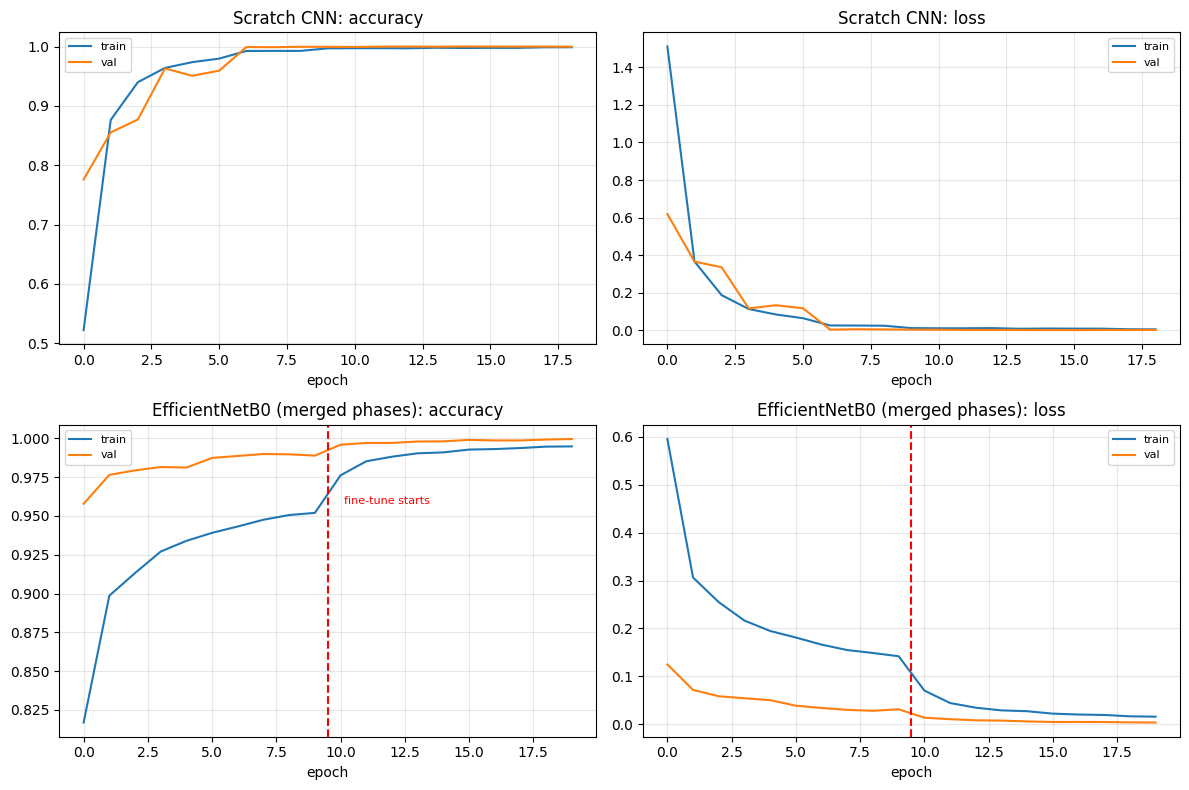

In [ ]:
hs, he = hist_scratch.history, merged_hist

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(hs["accuracy"], label="train")
axes[0, 0].plot(hs["val_accuracy"], label="val")
axes[0, 0].set_title("Scratch CNN: accuracy")
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(hs["loss"], label="train")
axes[0, 1].plot(hs["val_loss"], label="val")
axes[0, 1].set_title("Scratch CNN: loss")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(he["accuracy"], label="train")
axes[1, 0].plot(he["val_accuracy"], label="val")
axes[1, 0].axvline(boundary - 0.5, ls="--", color="red")
axes[1, 0].text(boundary + 0.15, min(he["val_accuracy"]),
                "fine-tune starts", color="red", fontsize=8)
axes[1, 0].set_title("EfficientNetB0 (merged phases): accuracy")
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(he["loss"], label="train")
axes[1, 1].plot(he["val_loss"], label="val")
axes[1, 1].axvline(boundary - 0.5, ls="--", color="red")
axes[1, 1].set_title("EfficientNetB0 (merged phases): loss")
axes[1, 1].legend(fontsize=8)

for ax in axes.ravel():
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(os.path.join(REPORT_DIR, "training_curves.png"), dpi=130)
plt.show()


###Interpretation guide:
Notes on how to read the comparison above: whether the accuracy gap (if any) justifies EfficientNetB0's extra size, why per-image latency matters for how smooth the webcam demo will feel, and why the exported model sizes stay comfortably within the web app's deployment memory budget.

## 13. Export Contract Artefacts:
Saves both trained models to disk in `.keras` format, along with the class name list and a JSON summary of accuracy, parameter count, and epochs trained for each model. Then runs a series of assertions to confirm every exported file exists, is non-empty, and matches the expected structure, and writes a manifest file recording the run's environment and output file sizes.

In [ ]:
scratch_model.save(os.path.join(EXPORT_DIR, "asl_scratch_cnn.keras"))
effnet_model.save(os.path.join(EXPORT_DIR, "asl_efficientnetb0_finetuned.keras"))

with open(os.path.join(EXPORT_DIR, "class_names.json"), "w") as fh:
    json.dump(class_names, fh, indent=2)

comparison_rows = [
    {"Model": "Scratch CNN",
     "Test Accuracy": float(test_acc_scratch),
     "Total Params": int(params_scratch),
     "Epochs Trained": int(len(hist_scratch.epoch))},
    {"Model": "EfficientNetB0 (fine-tuned)",
     "Test Accuracy": float(test_acc_effnet),
     "Total Params": int(params_effnet),
     "Epochs Trained": int(len(hist_p1.epoch) + len(hist_p2.epoch))},
]
with open(os.path.join(EXPORT_DIR, "model_comparison.json"), "w") as fh:
    json.dump(comparison_rows, fh, indent=2)

contract_files = ["asl_scratch_cnn.keras", "asl_efficientnetb0_finetuned.keras",
                  "class_names.json", "model_comparison.json"]
for fname in contract_files:
    p = os.path.join(EXPORT_DIR, fname)
    assert os.path.exists(p) and os.path.getsize(p) > 0, f"missing/empty artefact: {fname}"

assert isinstance(class_names, list) and len(class_names) == NUM_CLASSES
assert all(isinstance(c, str) for c in class_names)

with open(os.path.join(EXPORT_DIR, "model_comparison.json")) as fh:
    rows_check = json.load(fh)
assert len(rows_check) == 2
expected_keys = {"Model", "Test Accuracy", "Total Params", "Epochs Trained"}
for row in rows_check:
    assert set(row.keys()) == expected_keys, f"bad keys: {sorted(row.keys())}"
assert rows_check[0]["Model"] == "Scratch CNN"
assert "EfficientNet" in rows_check[1]["Model"]
for row in rows_check:
    assert 0 < row["Test Accuracy"] <= 1, "accuracy must be a 0-1 fraction"
    assert isinstance(row["Total Params"], int)
    assert isinstance(row["Epochs Trained"], int)

with open(os.path.join(REPORT_DIR, "run_manifest.txt"), "w") as fh:
    fh.write(f"TensorFlow {tf.__version__} | Keras {keras.__version__} | seed {SEED}\n")
    fh.write(f"finished {datetime.datetime.now().isoformat(timespec='seconds')}\n")
    for fname in contract_files:
        fp = os.path.join(EXPORT_DIR, fname)
        fh.write(f"{fname}: {os.path.getsize(fp)} bytes\n")

for fname in contract_files:
    p = os.path.join(EXPORT_DIR, fname)
    print(f"  {fname:38s} {os.path.getsize(p):>12,d} bytes")


  asl_scratch_cnn.keras                    14,095,501 bytes
  asl_efficientnetb0_finetuned.keras       32,966,774 bytes
  class_names.json                                217 bytes
  model_comparison.json                           279 bytes


#Conclusions

##Performance
Both models performed excellently on the held-out test set. The Scratch CNN reached 99.99% test accuracy (macro-F1 0.9999) with only 1.17M parameters, training for 19 of 25 epochs before early stopping, at ~78.5ms mean inference latency and a 14.1MB export size. The fine-tuned EfficientNet-B0 reached 99.91% test accuracy (macro-F1 0.9991) with 4.38M parameters across 20 epochs, ~86.1ms mean latency, and a 33.0MB export size. Given how close the two models are, the extra size and computational cost of EfficientNet-B0 is not clearly justified here; the Scratch CNN is smaller, faster, and more accurate, which suggests the ASL Alphabet dataset (plain background, one subject, consistent framing) is constrained enough that a simple, purpose-built CNN can already solve it near-perfectly without needing pretrained features.

##Strengths and weaknesses
The Scratch CNN's strength is efficiency without sacrificing accuracy: at 1.17M parameters it is 3.75× smaller than EfficientNet-B0, exports to 14.1MB, and answers in ~78.5ms, while matching or slightly exceeding EfficientNet-B0 on this dataset. Its weakness is that everything it knows was learned purely from these 87,000 studio-quality images, so it likely has less built-in robustness to inputs outside that narrow distribution (different skin tones, backgrounds, or lighting) than a pretrained network would. EfficientNet-B0's strength is the opposite side of that coin: its ImageNet pretraining gives it a broader, more general visual vocabulary, and unfreezing its last 30 layers produced a genuine ~1.0-point validation-accuracy gain over frozen feature extraction, confirming fine-tuning did real work. Its weakness here is cost without a matching benefit on this specific, visually constrained dataset it needed more parameters, a larger export, and higher latency to land at essentially the same accuracy as the simpler model.

##Error behaviour
Error analysis reinforces this picture. The Scratch CNN's single mistake (M misread as A, 56% confidence) traces to a genuine outlier photo, a hand raised into a shadowed ceiling corner rather than the dataset's usual plain, evenly-lit background which could be pointing to a data-quality artifact rather than a real handshape weakness. EfficientNet-B0's eight errors, by contrast, all fall between visually adjacent ASL letter pairs (N/M, F/K, U/R, W/V), which are genuinely close handshapes in real ASL. Both error patterns are reassuring in the same way: neither model is failing on a systematic weak class, and EfficientNet-B0's mistakes reflect real-world visual ambiguity rather than a modelling flaw.

##Tradeoffs
The practical trade-off is explicit: EfficientNet-B0 costs an extra 3.2M parameters, a ~2.3× larger export size, and ~10% higher per-image latency, in exchange for a 0.08-percentage-point accuracy difference that actually runs the other way, in the Scratch CNN's favour, on this test set. For a lightweight web or mobile ASL-translation deployment, where download size and per-frame latency directly affect user experience, the Scratch CNN is the more sensible choice given this dataset. That trade-off would likely flip in a setting with more visual diversity than this dataset offers, where EfficientNet-B0's pretrained features would have a genuine opportunity to earn back their extra cost.

##Future improvements
1. Test both models on real webcam captures rather than only Kaggle's studio images, to see whether EfficientNet-B0's pretrained robustness pays off once real-world lighting and framing are introduced.
2. Add a hand-detection/cropping step before classification, so the model focuses on the hand itself rather than background or sleeve.
3. Extend to a sequence-aware model (e.g. a short-clip CNN or ConvLSTM) so the two motion letters, J and Z, can be represented properly instead of approximated from a single frame.
4. Apply quantization or pruning to EfficientNet-B0 to shrink its size and latency, so its transfer-learning benefits could be kept without the current cost penalty.
5. Broaden the training data with more diverse skin tones, backgrounds, and lighting, to properly test whether pretrained features provide the generalisation benefit this constrained dataset couldn't reveal.
